In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

In [33]:
df = pd.read_csv("heart_disease_uci.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [34]:
print("\nMissing values per column:\n", df.isna().sum())


Missing values per column:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [36]:
if "target" in df.columns:
    target_col = "target"
elif "num" in df.columns:
    target_col = "num"
    df[target_col] = (df[target_col] > 0).astype(int)  # convert 0-4 into 0/1
else:
    raise ValueError("Target column not found. Expected 'target' or 'num'.")

In [37]:
for col in df.columns:
    if df[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:\n", df.isna().sum())



Missing values after cleaning:
 id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


C:\Users\ayesh\AppData\Local\Temp\ipykernel_26168\3398040871.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])
C:\Users\ayesh\AppData\Local\Temp\ipykernel_26168\3398040871.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


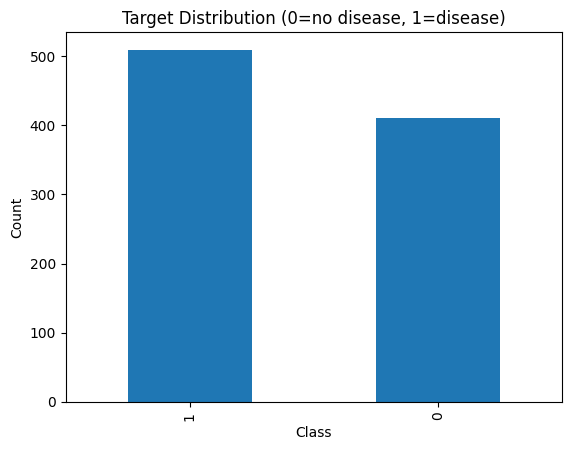

In [38]:
# Target distribution
df[target_col].value_counts().plot(kind="bar")
plt.title("Target Distribution (0=no disease, 1=disease)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


Correlation with target:
 num         1.000000
exang       0.433605
oldpeak     0.366138
id          0.356086
age         0.282700
ca          0.164755
fbs         0.108071
trestbps    0.101273
chol       -0.228976
thalch     -0.381864
Name: num, dtype: float64


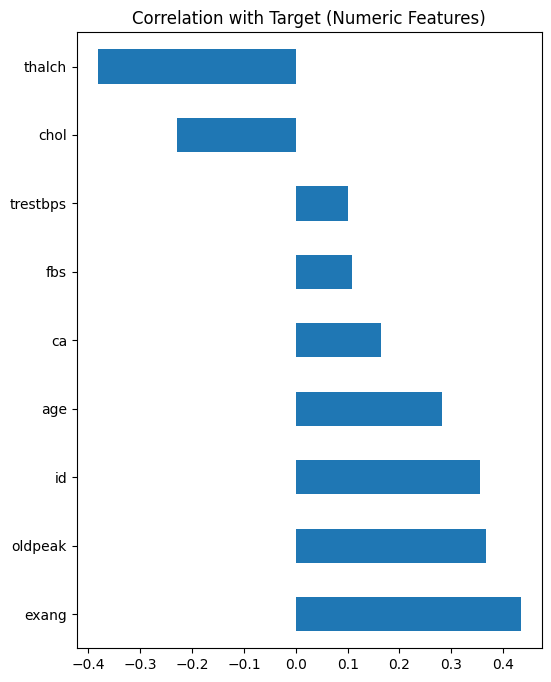

In [39]:
# Correlation with target (only numeric columns)
corr = df.corr(numeric_only=True)[target_col].sort_values(ascending=False)
print("\nCorrelation with target:\n", corr)

corr.drop(target_col).plot(kind="barh", figsize=(6, 8))
plt.title("Correlation with Target (Numeric Features)")
plt.show()

In [40]:
X = df.drop(columns=[target_col])
y = df[target_col]

# Convert ALL categorical/text columns to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

print("\nX shape after get_dummies:", X.shape)
print("Any non-numeric columns left?", (X.dtypes == "object").any())


X shape after get_dummies: (920, 22)
Any non-numeric columns left? False


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [46]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [47]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(acc, 4))


Accuracy: 0.8696


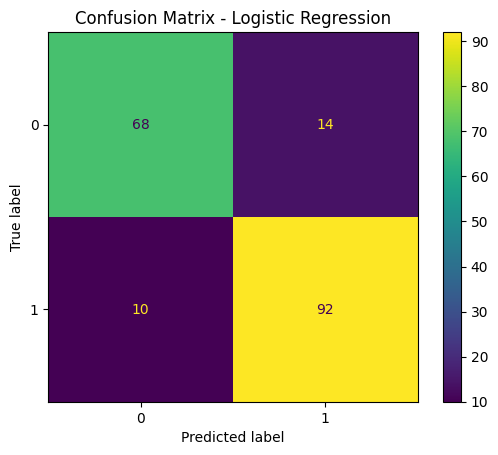

In [48]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [49]:
# ROC-AUC
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.9346


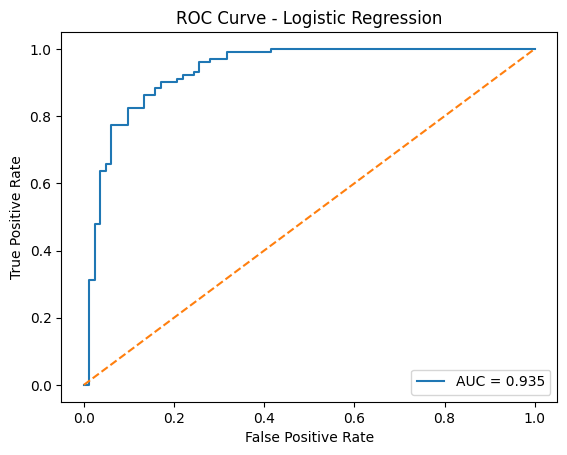

In [50]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values("Abs_Coefficient", ascending=False)

print("\nTop 10 Important Features:")
display(feature_importance.head(10))


Top 10 Important Features:


,Feature,Coefficient,Abs_Coefficient
0,id,1.893213,1.893213
12,dataset_VA Long Beach,-1.270805,1.270805
8,ca,0.742732,0.742732
13,cp_atypical angina,-0.695964,0.695964
10,dataset_Hungary,-0.666736,0.666736
7,oldpeak,0.658021,0.658021
6,exang,0.468187,0.468187
9,sex_Male,0.441410,0.441410
14,cp_non-anginal,-0.400590,0.400590
18,slope_flat,0.342423,0.342423


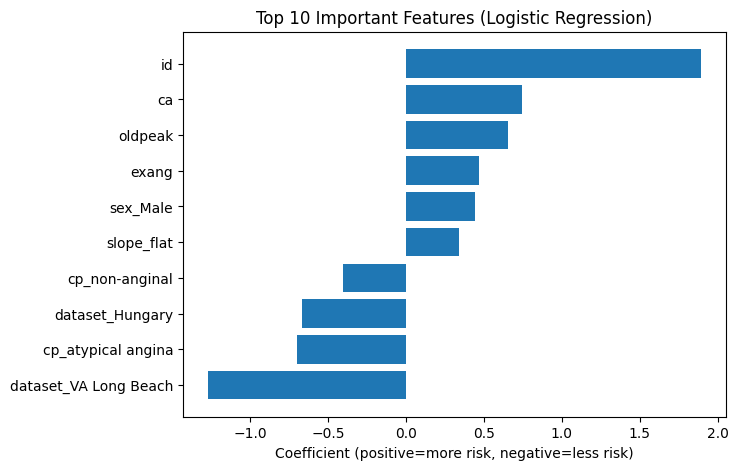

In [52]:
# Plot top 10
top10 = feature_importance.head(10).sort_values("Coefficient")
plt.figure(figsize=(7, 5))
plt.barh(top10["Feature"], top10["Coefficient"])
plt.title("Top 10 Important Features (Logistic Regression)")
plt.xlabel("Coefficient (positive=more risk, negative=less risk)")
plt.show()
